# Neural Networks — Credit Card Fraud Detection

## Overview
In this notebook, we implement a **Feed-Forward Neural Network (Multi-Layer Perceptron)** from scratch and apply it to detect fraudulent credit card transactions.

We cover:
- Neural network architecture and forward propagation
- Backpropagation and gradient descent
- Activation functions (ReLU, Sigmoid)
- Training with Mini-Batch SGD
- Evaluation using accuracy, precision, recall, and F1-score

## What is a Neural Network?
A feed-forward neural network consists of layers of neurons. Each layer applies a linear transformation followed by a non-linear activation function:

$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$$
$$a^{(l)} = f(z^{(l)})$$

The network is trained by minimizing the **Binary Cross-Entropy Loss** using **backpropagation** to compute gradients and **gradient descent** to update weights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/credit_fraud/creditcard.csv')

fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(len(fraud), random_state=42)
df_balanced = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_balanced.drop('Class', axis=1).values
y = df_balanced['Class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (787, 30)
Test set size: (197, 30)


## 2. Neural Network from Scratch

In [3]:
class NeuralNetwork:
    def __init__(self, layer_sizes, lr=0.01, epochs=100, batch_size=32):
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.weights = []
        self.biases = []
        self.losses = []
        self._init_weights()

    def _init_weights(self):
        for i in range(len(self.layer_sizes) - 1):
            W = np.random.randn(self.layer_sizes[i], self.layer_sizes[i+1]) * 0.01
            b = np.zeros((1, self.layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        self.activations = [X]
        self.z_values = []
        a = X
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = a @ W + b
            self.z_values.append(z)
            if i == len(self.weights) - 1:
                a = self.sigmoid(z)
            else:
                a = self.relu(z)
            self.activations.append(a)
        return a

    def backward(self, X, y):
        m = X.shape[0]
        y = y.reshape(-1, 1)
        delta = self.activations[-1] - y
        grads_w, grads_b = [], []
        for i in reversed(range(len(self.weights))):
            dW = self.activations[i].T @ delta / m
            db = delta.mean(axis=0, keepdims=True)
            grads_w.insert(0, dW)
            grads_b.insert(0, db)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.relu_deriv(self.z_values[i-1])
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * grads_w[i]
            self.biases[i] -= self.lr * grads_b[i]

    def fit(self, X, y):
        for epoch in range(self.epochs):
            idx = np.random.permutation(len(X))
            X, y = X[idx], y[idx]
            for start in range(0, len(X), self.batch_size):
                X_batch = X[start:start+self.batch_size]
                y_batch = y[start:start+self.batch_size]
                self.forward(X_batch)
                self.backward(X_batch, y_batch)
            y_pred = self.forward(X)
            loss = -np.mean(y.reshape(-1,1) * np.log(y_pred + 1e-9) +
                           (1 - y.reshape(-1,1)) * np.log(1 - y_pred + 1e-9))
            self.losses.append(loss)
            if epoch % 10 == 0:
                print(f"Epoch {epoch} — Loss: {loss:.4f}")

    def predict(self, X, threshold=0.5):
        return (self.forward(X) >= threshold).astype(int).flatten()

# Train
nn = NeuralNetwork(layer_sizes=[X_train_scaled.shape[1], 64, 32, 1], lr=0.01, epochs=50, batch_size=32)
nn.fit(X_train_scaled, y_train)

Epoch 0 — Loss: 0.6931
Epoch 10 — Loss: 0.6928
Epoch 20 — Loss: 0.6927
Epoch 30 — Loss: 0.6927
Epoch 40 — Loss: 0.6926


In [4]:
# Evaluate
y_pred_scratch = nn.predict(X_test_scaled)
print("From Scratch:")
print(classification_report(y_test, y_pred_scratch))

From Scratch:
              precision    recall  f1-score   support

           0       0.44      1.00      0.61        87
           1       0.00      0.00      0.00       110

    accuracy                           0.44       197
   macro avg       0.22      0.50      0.31       197
weighted avg       0.20      0.44      0.27       197



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


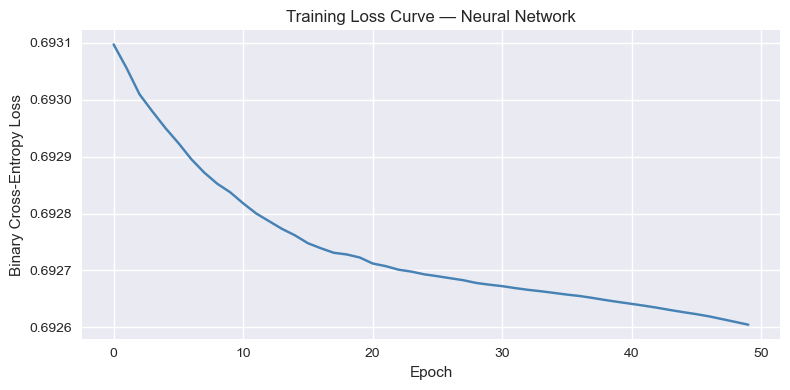

In [5]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(nn.losses, color='steelblue')
plt.title('Training Loss Curve — Neural Network')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.tight_layout()
plt.show()

## 3. Neural Network with Scikit-Learn

In [6]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42, early_stopping=True)
mlp.fit(X_train_scaled, y_train)

y_pred_sklearn = mlp.predict(X_test_scaled)
print("Scikit-Learn MLP:")
print(classification_report(y_test, y_pred_sklearn))

Scikit-Learn MLP:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91        87
           1       0.98      0.86      0.92       110

    accuracy                           0.91       197
   macro avg       0.91      0.92      0.91       197
weighted avg       0.92      0.91      0.91       197



## 4. Evaluation & Visualization

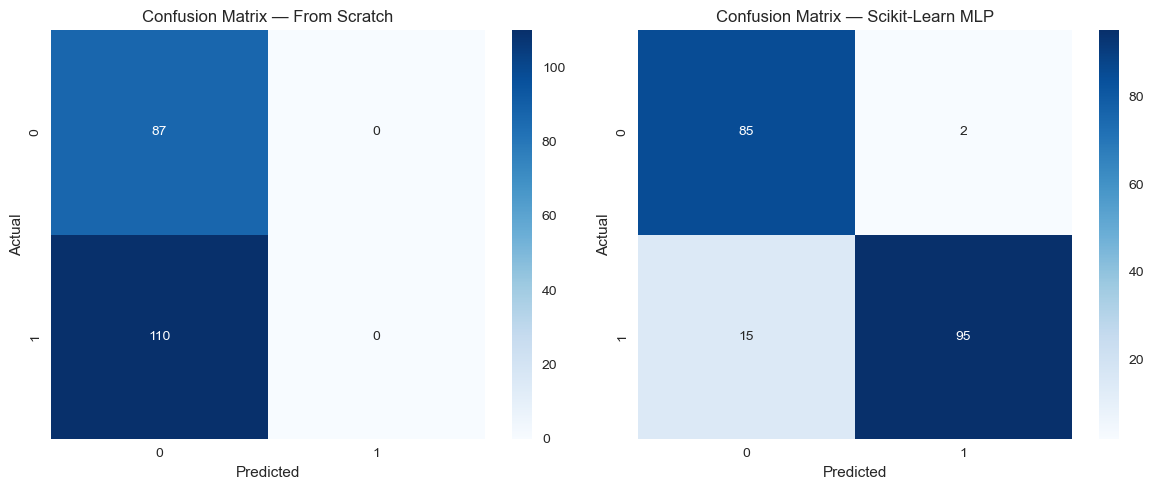

In [7]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                               [y_pred_scratch, y_pred_sklearn],
                               ['From Scratch', 'Scikit-Learn MLP']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 5. Conclusion

In this notebook, we implemented a feed-forward neural network from scratch for fraud detection.

Key takeaways:
- Our from-scratch MLP uses ReLU activations in hidden layers and sigmoid in the output layer for binary classification.
- Mini-batch gradient descent speeds up training compared to full-batch gradient descent.
- The loss curve shows steady convergence over training epochs.
- Neural networks are powerful but require careful tuning of architecture, learning rate, and regularization.
- Scikit-learn's MLPClassifier provides a convenient baseline with early stopping to prevent overfitting.